In [29]:
import pandas as pd
import numpy as np


# 1. Load the CSV file
df = pd.read_csv('NORS_20251104.csv')

print(df.info())

# 1. Clean the string column by removing commas
df['Illnesses'] = df['Illnesses'].astype(str).str.replace(',', '', regex=False)

# 2. Convert to numeric (float), coercing any remaining non-numeric values to NaN
# 'errors='coerce' is crucial for handling mixed types and non-numeric strings
df['Illnesses'] = pd.to_numeric(df['Illnesses'], errors='coerce')
df['Illnesses'] = df['Illnesses'].astype('int64')
# Get the actual list of illnesses states
unique_illnesses_list = df['Illnesses'].unique()

# The list of columns you want to modify
features_to_fill = ['Illnesses', 'Hospitalizations', 'Deaths']

# Replace NaNs with 0 only in the specified columns
df[features_to_fill] = df[features_to_fill].fillna(0)

print(df.info())
print(df.describe())

hosp_above_zero = df[df['Hospitalizations'] > 0]
print("number of rows that have hospitalizations above 0:", len(hosp_above_zero))
death_above_zero = df[df['Deaths'] > 0]
print("number of rows that have death above 0:", len(death_above_zero))

df.head(100)


C:\Users\jared\AppData\Local\Temp\ipykernel_6788\1627255454.py:6: DtypeWarning: Columns (8,10,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('NORS_20251104.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66713 entries, 0 to 66712
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          66713 non-null  int64  
 1   Month                         66713 non-null  int64  
 2   State                         66713 non-null  object 
 3   Primary Mode                  66713 non-null  object 
 4   Etiology                      50375 non-null  object 
 5   Serotype or Genotype          16470 non-null  object 
 6   Etiology Status               50375 non-null  object 
 7   Setting                       60804 non-null  object 
 8   Illnesses                     66713 non-null  object 
 9   Hospitalizations              58155 non-null  float64
 10  Info On Hospitalizations      58480 non-null  object 
 11  Deaths                        58785 non-null  float64
 12  Info On Deaths                58463 non-null  object 
 13  F

,Year,Month,State,Primary Mode,Etiology,Serotype or Genotype,Etiology Status,Setting,Illnesses,Hospitalizations,Info On Hospitalizations,Deaths,Info On Deaths,Food Vehicle,Food Contaminated Ingredient,IFSAC Category,Water Exposure,Water Type,Animal Type
0,1971,2,California,Water,Copper,NaN,Confirmed,Restaurant,2,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Drinking water,Community,NaN
1,1971,6,Arkansas,Water,Hepatitis A,NaN,Confirmed,Store,98,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Drinking water,Other,NaN
2,1971,6,Missouri,Water,Unknown,NaN,Suspected,Subdivision/Neighborhood,2,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Drinking water,Community,NaN
3,1971,6,Alabama,Water,Selenium,NaN,Confirmed,Unknown,3,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Drinking water,Individual/Private,NaN
4,1971,6,Vermont,Water,Unknown,NaN,Suspected,Community/municipality,3,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Drinking water,Community,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1974,9,Utah,Water,Giardia duodenalis,NaN,Confirmed,Backcountry/wilderness area,34,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Other/Environmental water,NaN,NaN
96,1974,9,Pennsylvania,Water,Legionella pneumophila,unknown,Confirmed,Hotel/motel,11,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Undetermined water,NaN,NaN
97,1974,9,New York,Water,Chromium,NaN,Confirmed,Office/indoor workplace,20,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Drinking water,Community,NaN
98,1974,10,Pennsylvania,Water,Unknown,NaN,Suspected,Restaurant,18,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Drinking water,Other,NaN


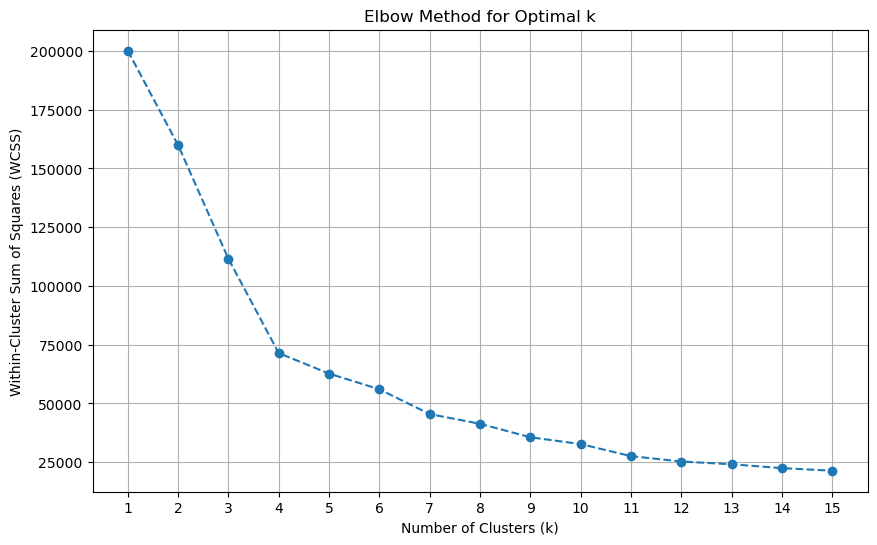

WCSS values for k=1 to 10:
1     200136.000000
2     159964.863017
3     111576.734682
4      71420.268943
5      62698.594075
6      56007.961150
7      45451.132471
8      41317.543690
9      35590.970207
10     32691.313509
11     27549.957400
12     25266.818445
13     24093.023979
14     22447.574501
15     21346.963835
dtype: float64


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create the new feature: Hospitalizations per Illness
df['hosp_per_ill'] = df['Hospitalizations'].divide(df['Illnesses']).fillna(0)

# Create the new feature: Deaths per Illness
df['death_per_ill'] = df['Deaths'].divide(df['Illnesses']).fillna(0)

df_no_outlier = df.drop(index=[871])
# 199, 119, 202, 317, 512, 651, 674, 814, 947, 13225

# Your specified features
features = ['Year', 'Month', 'Illnesses']
X = df_no_outlier[features] # Assumes your DataFrame df is already loaded

# 1. Z-transformation (Standard Scaling)
# Standard Scaler performs the Z-transformation: (x - mean) / standard deviation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Rerun your K-Means models using X_scaled_robust

# 2. Elbow Method with WCSS (Inertia)
wcss = []
k_range = range(1, 16)
random_seed = 123 # Set seed for reproducibility, as requested

for i in k_range:
    # Initialize K-Means with the specified seed and k value
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=random_seed, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # .inertia_ is the WCSS

# 3. Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.xticks(k_range)
plt.show()

# Optional: Print WCSS values to help with elbow determination
print("WCSS values for k=1 to 10:")
print(pd.Series(wcss, index=k_range))

In [31]:
from sklearn.cluster import KMeans
import pandas as pd


# Define the k values you want to test
k_values_to_test = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
random_seed = 123 # Keep the seed for reproducibility

print("Fitting K-Means models for k=2-15")
print("-" * 40)

for k in k_values_to_test:
    # 1. Initialize the K-Means model
    kmeans_k = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=random_seed,
        n_init='auto'
    )

    # 2. Fit and predict the cluster labels
    # Assign labels to a new column specific to that k (e.g., 'Cluster_k3')
    column_name = f'Cluster_k{k}'
    df_no_outlier[column_name] = kmeans_k.fit_predict(X_scaled)

    # 3. Print the results for this k
    print(f"\nCluster Sizes for k={k}:")
    print(df_no_outlier[column_name].value_counts())
    print("-" * 40)



Fitting K-Means models for k=2-15
----------------------------------------

Cluster Sizes for k=2:
Cluster_k2
0    66697
1       15
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=3:
Cluster_k3
2    33960
0    19369
1    13383
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=4:
Cluster_k4
2    33972
0    19374
1    13353
3       13
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=5:
Cluster_k5
2    26949
0    18669
4    12706
1     8375
3       13
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=6:
Cluster_k6
5    18304
2    16850
0    16320
1     8133
4     7092
3       13
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=7:
Cluster_k7
5    18268
2    16839
0    16320
1     8053
4     7203
3       25
6        4
Name: count, dtype: int64
----------------------------------------

Cluster Sizes f

In [32]:
# The dataframe 'df' already has the 'Cluster_k3' column added from your previous code
single_point_cluster = df_no_outlier[df_no_outlier['Cluster_k3'] == 2]

print("Data point in the single-item cluster (Cluster 1):")
print(single_point_cluster)

#ten_point_cluster = df_no_outlier[df_no_outlier['Cluster_k4']==2]
#print("Data points in the 10-itme cluster are:")
#print(ten_point_cluster)


Data point in the single-item cluster (Cluster 1):
       Year  Month           State      Primary Mode                Etiology  \
10390  2005      1        Maryland              Food                     NaN   
10391  2005      1      Washington              Food   Norovirus Genogroup I   
10392  2005      1         Florida              Food                     NaN   
10393  2005      1  South Carolina              Food       Norovirus unknown   
10394  2005      1            Ohio              Food   Norovirus Genogroup I   
...     ...    ...             ...               ...                     ...   
65443  2023      6       Wisconsin  Person-to-person  Norovirus Genogroup II   
65444  2023      6  North Carolina  Person-to-person       Norovirus unknown   
65445  2023      6            Ohio              Food                     NaN   
65446  2023      6            Ohio  Person-to-person   Norovirus Genogroup I   
65447  2023      6            Utah              Food                 

In [8]:
# 1. Get the size of each cluster for k=10
cluster_counts = df_no_outlier['Cluster_k10'].value_counts()

# 2. Define the size threshold
min_size_threshold = 1000

# 3. Identify the labels of the clusters to KEEP (size > 1000)
# These are the major, meaningful clusters
labels_to_keep = cluster_counts[cluster_counts > min_size_threshold].index.tolist()

# 4. Filter the DataFrame to keep only the rows belonging to the large clusters
df_no_outlier_for_real = df_no_outlier[df_no_outlier['Cluster_k10'].isin(labels_to_keep)].copy()

print("--- Filtering Results ---")
print(f"Cluster Labels to KEEP (size > {min_size_threshold}): {labels_to_keep}")
print(f"Original Data Size (df_no_outlier): {len(df_no_outlier)}")
print(f"Cleaned Data Size (df_no_outlier_for_real): {len(df_no_outlier_for_real)}")
print(f"Number of Outliers Dropped: {len(df_no_outlier) - len(df_no_outlier_for_real)}")
print("-------------------------")

--- Filtering Results ---
Cluster Labels to KEEP (size > 1000): [0, 3, 6, 7]
Original Data Size (df_no_outlier): 66702
Cleaned Data Size (df_no_outlier_for_real): 66238
Number of Outliers Dropped: 464
-------------------------


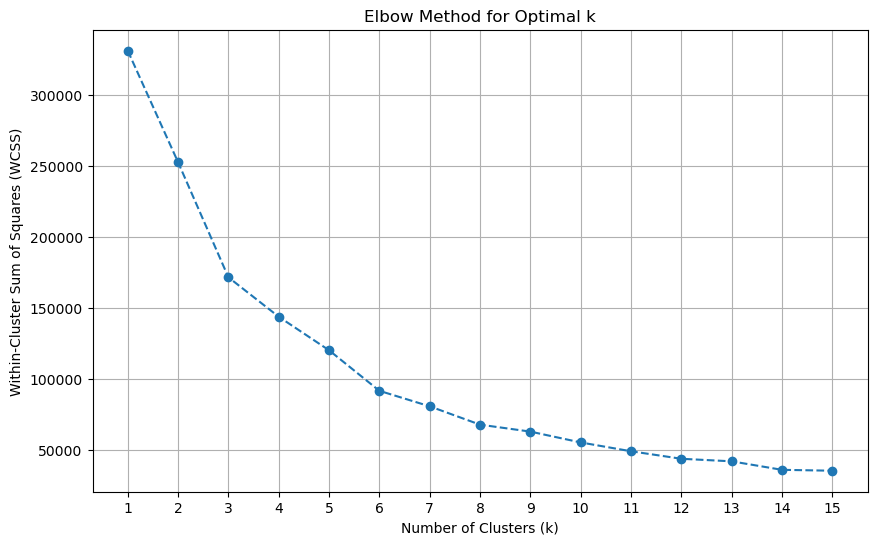

WCSS values for k=1 to 10:
1     331190.000000
2     252664.980714
3     171628.482928
4     143864.636146
5     120243.250531
6      91688.352064
7      80771.779161
8      67863.529782
9      62972.510324
10     55341.258016
11     49131.597564
12     43841.396748
13     42041.236359
14     36060.053110
15     35426.074302
dtype: float64


In [9]:

# Your specified features
features = ['Illnesses', 'Hospitalizations', 'Deaths', 'hosp_per_ill', 'death_per_ill']
X = df_no_outlier_for_real[features] # Assumes your DataFrame df is already loaded

# 1. Z-transformation (Standard Scaling)
# Standard Scaler performs the Z-transformation: (x - mean) / standard deviation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Rerun your K-Means models using X_scaled_robust

# 2. Elbow Method with WCSS (Inertia)
wcss = []
k_range = range(1, 16)
random_seed = 123 # Set seed for reproducibility, as requested

for i in k_range:
    # Initialize K-Means with the specified seed and k value
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=random_seed, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # .inertia_ is the WCSS

# 3. Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.xticks(k_range)
plt.show()

# Optional: Print WCSS values to help with elbow determination
print("WCSS values for k=1 to 10:")
print(pd.Series(wcss, index=k_range))

In [10]:
from sklearn.cluster import KMeans
import pandas as pd


# Define the k values you want to test
k_values_to_test = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
random_seed = 123 # Keep the seed for reproducibility

print("Fitting K-Means models for k=2-15")
print("-" * 40)

for k in k_values_to_test:
    # 1. Initialize the K-Means model
    kmeans_k = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=random_seed,
        n_init='auto'
    )

    # 2. Fit and predict the cluster labels
    # Assign labels to a new column specific to that k (e.g., 'Cluster_k3')
    column_name = f'Cluster_k{k}'
    df_no_outlier_for_real[column_name] = kmeans_k.fit_predict(X_scaled)

    # 3. Print the results for this k
    print(f"\nCluster Sizes for k={k}:")
    print(df_no_outlier_for_real[column_name].value_counts())
    print("-" * 40)



Fitting K-Means models for k=2-15
----------------------------------------

Cluster Sizes for k=2:
Cluster_k2
1    61458
0     4780
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=3:
Cluster_k3
1    61040
0     4041
2     1157
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=4:
Cluster_k4
1    60435
0     4301
2     1146
3      356
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=5:
Cluster_k5
1    60435
0     4302
2      968
3      353
4      180
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=6:
Cluster_k6
1    60607
0     3918
2      952
3      545
4      180
5       36
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=7:
Cluster_k7
1    60432
0     3932
2      952
3      526
6      196
4      180
5       20
Name: count, dtype: int64
----------------------------------------

Cluster Sizes f

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Define the Function ---
def plot_cluster_relative_frequencies(df, cluster_column_name, categorical_features):
    """
    Generates bar plots showing the relative frequency of categorical features
    within each cluster.

    Args:
        df (pd.DataFrame): The DataFrame containing features and cluster labels.
        cluster_column_name (str): The name of the cluster column (e.g., 'Cluster_k4').
        categorical_features (list): A list of categorical column names to plot.
    """
    num_clusters = df[cluster_column_name].nunique()
    
    # Calculate the number of rows and columns for the subplot grid
    n_features = len(categorical_features)
    n_cols = 3 
    n_rows = (n_features + n_cols - 1) // n_cols # Ceiling division

    plt.figure(figsize=(n_cols * 5, n_rows * 5))
    plt.suptitle(f'Relative Frequency of Categorical Features per Cluster (k={num_clusters})', 
                 fontsize=16, y=1.02)
    
    # Iterate through each categorical feature
    for i, feature in enumerate(categorical_features):
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Calculate the relative frequency (proportions)
        # 1. Group by Cluster and Feature
        # 2. Count the occurrences (size())
        # 3. Divide by the total count within each Cluster (level=0)
        proportions = df.groupby(cluster_column_name)[feature].value_counts(normalize=True).mul(100).rename('Percent').reset_index()

        # Plot the result
        sns.barplot(
            x=feature, 
            y='Percent', 
            hue=cluster_column_name, 
            data=proportions,
            palette='viridis'
        )
        
        plt.title(f'Feature: {feature}')
        plt.ylabel('Relative Frequency (%)')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Cluster')
        plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle

    plt.show()

# --- 2. Define Inputs ---
# These are the categorical columns you requested
categorical_features = [
    'Year', 'Month', 'State', 'Primary Mode', 'Food Vehicle', 
    'Etiology', 'Setting', 'Water Exposure', 'Water Type', 'Animal Type'
]

# --- 3. Execute the Plots for k=3, k=4, and k=5 ---

# NOTE: The cluster columns are created in the previous code cell,
# so we assume 'Cluster_k3', 'Cluster_k4', and 'Cluster_k5' exist in df.

print("Generating plots for k=3...")
plot_cluster_relative_frequencies(df, 'Cluster_k3', categorical_features)

print("Generating plots for k=4...")
plot_cluster_relative_frequencies(df, 'Cluster_k4', categorical_features)

print("Generating plots for k=5...")
plot_cluster_relative_frequencies(df, 'Cluster_k5', categorical_features)

Generating plots for k=3...


KeyError: 'Cluster_k3'

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from collections import Counter # Useful for finding top categories

# Define your column names (from your previous R code translation)
feature_cols = [
    'Illnesses',
    'Hospitalizations',
    'Deaths',
    'hosp_per_ill',
    'death_per_ill'
]

# Convert the array to a DataFrame with column names
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

# Calculate the correlation matrix
print(X_scaled_df.corr())

# Pair plots (equivalent to pairs(num_vars) but more advanced)
# sns.pairplot(num_vars) # This can be very slow for a large dataset
# plt.suptitle("Pair Plots of Numeric Variables", y=1.02)
# plt.show()

                  Illnesses  Hospitalizations  Deaths  hosp_per_ill  \
Illnesses               NaN               NaN     NaN           NaN   
Hospitalizations        NaN               NaN     NaN           NaN   
Deaths                  NaN               NaN     NaN           NaN   
hosp_per_ill            NaN               NaN     NaN           NaN   
death_per_ill           NaN               NaN     NaN           NaN   

                  death_per_ill  
Illnesses                   NaN  
Hospitalizations            NaN  
Deaths                      NaN  
hosp_per_ill                NaN  
death_per_ill               NaN  


In [20]:
## I. Explore Correlations Among Variables
print("Correlation Matrix:")
print(X_scaled_df.corr()) # Equivalent to cor(num_vars)

# Pair plots (equivalent to pairs(num_vars) but more advanced)
# sns.pairplot(num_vars) # This can be very slow for a large dataset
# plt.suptitle("Pair Plots of Numeric Variables", y=1.02)
# plt.show()

Correlation Matrix:
                  Illnesses  Hospitalizations  Deaths  hosp_per_ill  \
Illnesses               NaN               NaN     NaN           NaN   
Hospitalizations        NaN               NaN     NaN           NaN   
Deaths                  NaN               NaN     NaN           NaN   
hosp_per_ill            NaN               NaN     NaN           NaN   
death_per_ill           NaN               NaN     NaN           NaN   

                  death_per_ill  
Illnesses                   NaN  
Hospitalizations            NaN  
Deaths                      NaN  
hosp_per_ill                NaN  
death_per_ill               NaN  


In [8]:
## II. Dimensionality Reduction using Principal Component Analysis

# Instantiate PCA: The 'scale.' argument in R's prcomp is handled by the data you feed it.
# We assume 'X_scaled' is the standardized data, so no need to scale again.
pca = PCA()
pca_result = pca.fit(num_vars) # Use num_vars (assuming it is the scaled data X_scaled)

# Summary of PCA
print("\nPCA Explained Variance Ratios:")
print(pd.DataFrame({
    'PC': range(1, len(pca_result.explained_variance_ratio_) + 1),
    'Variance Explained': pca_result.explained_variance_ratio_.round(4),
    'Cumulative Variance': pca_result.explained_variance_ratio_.cumsum().round(4)
}))

# Scree Plot (equivalent to plot(pca_result, type = "l"))
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(pca_result.explained_variance_ratio_) + 1), 
         pca_result.explained_variance_ratio_, 
         'o-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.grid()
plt.show()

# Extracted PCA scores
pca_scores = pd.DataFrame(
    pca_result.transform(num_vars)[:, 0:3], # Extract first 3 PCs
    columns=['PC1', 'PC2', 'PC3'],
    index=clean_df.index # Keep the original index for joining
)
print("\nPCA Scores (First 3 Components):")
print(pca_scores.head())

NameError: name 'num_vars' is not defined

In [9]:
## I. K-Means
# The R code uses 'set.seed(123)', 'centers=3', 'nstart=25'
# random_state is the seed, n_clusters is centers, n_init is nstart
np.random.seed(123) # Set NumPy seed for reproducibility

kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=25,
    random_state=123 # Use a fixed random state
)

# Fit K-Means on the PCA scores
kmeans_result = kmeans.fit(pca_scores)

# Assign clusters back to the original DataFrame
# Note: Python clusters are 0-indexed, so 0, 1, 2. R clusters are 1-indexed (1, 2, 3).
clean_df['cluster'] = kmeans_result.labels_ 
# To match R's 1-indexed clusters, you can do: 
# clean_df['cluster'] = kmeans_result.labels_ + 1 
# We will use the standard 0-indexed labels for the characterization step.
clean_df['cluster'] = clean_df['cluster'].astype('category')


# Visualize (equivalent to fviz_cluster)
# Note: Python's fviz_cluster equivalent is harder to replicate exactly without the 'factoextra' package.
# A common way is to plot the first two principal components and color by cluster.
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue=clean_df['cluster'], 
    data=pca_scores.join(clean_df['cluster']), 
    palette='viridis', 
    legend='full', 
    alpha=0.6,
    s=50
)
plt.title('K-Means Clusters on PC1 and PC2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Save the plot
plt.savefig("PCA_kmeans_clusters.png", dpi=300, bbox_inches='tight')
plt.show()

print("K-Means clustering complete. Cluster labels saved in 'clean_df['cluster']'.")

NameError: name 'pca_scores' is not defined

In [10]:
## a. By Numeric Variables (Examine numeric variable summaries)
print("\nNumeric Variable Means by Cluster:")
cluster_means = clean_df.groupby('cluster')[feature_cols].mean()
print(cluster_means)


Numeric Variable Means by Cluster:


NameError: name 'clean_df' is not defined

In [11]:
## b. By Most Prevalent Primary Mode

# 1. Identify top primary modes causing illnesses
top_mode = clean_df.groupby('Primary_mode')['Illnesses'].sum() \
    .sort_values(ascending=False).index.tolist()
# NOTE: The R code here uses ALL modes, not just a top N, because 'pull(Primary_mode)' 
# extracts the entire reordered column. Let's use all modes for direct translation.

# 2 & 3. Prepare for plotting: Calculate proportions
mode_proportions = clean_df.groupby(['cluster', 'Primary_mode']).size().unstack(fill_value=0)
mode_proportions = mode_proportions.div(mode_proportions.sum(axis=1), axis=0).stack().reset_index(name='Proportion')

# 4. Plot (Equivalent to ggplot with geom_bar(position="fill") and coord_flip)
plt.figure(figsize=(8, 6))
# Order the x-axis (Primary_mode) by overall frequency (fct_infreq equivalent)
mode_order = clean_df['Primary_mode'].value_counts().index
sns.barplot(
    data=mode_proportions,
    x='Proportion', # x and y are swapped for coord_flip effect
    y='Primary_mode',
    hue='cluster',
    order=mode_order,
    palette='viridis'
)
plt.title("Cluster Composition by Primary Mode")
plt.xlabel("Proportion")
plt.ylabel("Primary_mode")
plt.legend(title='Cluster', loc='lower right')
plt.tight_layout()

# Save the plot
plt.savefig("Cluster_by_primary_mode.png", dpi=300, bbox_inches='tight')
plt.show()

# As a table (Equivalent to table(clean_df$Primary_mode, clean_df$cluster))
mode_cluster_tab = pd.crosstab(clean_df['Primary_mode'], clean_df['cluster'])
print("\nPrimary Mode Cross-Tabulation:")
print(mode_cluster_tab)

NameError: name 'clean_df' is not defined

In [12]:
## c. By Most Prevalent Etiologies

# 1. Identify top 50 etiologies causing illnesses
top_etiologies = clean_df.groupby('Etiology')['Illnesses'].sum() \
    .sort_values(ascending=False).head(50).index.tolist()

# 2. Filter dataset to those etiologies
df_top_etiology = clean_df[clean_df['Etiology'].isin(top_etiologies)].copy()

# 3 & 4. Plot (Equivalent to ggplot with geom_bar(position="fill") and coord_flip)
etiology_proportions = df_top_etiology.groupby(['cluster', 'Etiology']).size().unstack(fill_value=0)
etiology_proportions = etiology_proportions.div(etiology_proportions.sum(axis=1), axis=0).stack().reset_index(name='Proportion')

plt.figure(figsize=(8, 12)) # Adjusted size for 50 categories
# Order the y-axis (Etiology) by overall frequency (fct_infreq equivalent)
etiology_order = df_top_etiology['Etiology'].value_counts().index
sns.barplot(
    data=etiology_proportions,
    x='Proportion',
    y='Etiology',
    hue='cluster',
    order=etiology_order,
    palette='viridis'
)
plt.title("Cluster Composition by Top 50 Etiologies")
plt.xlabel("Proportion")
plt.ylabel("Etiology")
plt.legend(title='Cluster', loc='lower right')
plt.tight_layout()

# Save the plot
plt.savefig("Cluster_by_etiology.png", dpi=300, bbox_inches='tight')
plt.show()


NameError: name 'clean_df' is not defined

In [13]:
## d. By Most Prevalent Settings

# 1. Identify top 50 settings causing illnesses
top_settings = clean_df.groupby('Setting')['Illnesses'].sum() \
    .sort_values(ascending=False).head(50).index.tolist()

# 2. Filter dataset to those settings
df_top_setting = clean_df[clean_df['Setting'].isin(top_settings)].copy()

# 3 & 4. Plot (Equivalent to ggplot with geom_bar(position="fill") and coord_flip)
setting_proportions = df_top_setting.groupby(['cluster', 'Setting']).size().unstack(fill_value=0)
setting_proportions = setting_proportions.div(setting_proportions.sum(axis=1), axis=0).stack().reset_index(name='Proportion')

plt.figure(figsize=(8, 12)) # Adjusted size for 50 categories
# Order the y-axis (Setting) by overall frequency (fct_infreq equivalent)
setting_order = df_top_setting['Setting'].value_counts().index
sns.barplot(
    data=setting_proportions,
    x='Proportion',
    y='Setting',
    hue='cluster',
    order=setting_order,
    palette='viridis'
)
plt.title("Cluster Composition by Top 50 Settings")
plt.xlabel("Proportion")
plt.ylabel("Setting")
plt.legend(title='Cluster', loc='lower right')
plt.tight_layout()

# Save the plot
plt.savefig("Cluster_by_setting.png", dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'clean_df' is not defined

In [14]:
## e. By Season

# Prepare for plotting: Calculate proportions
season_proportions = clean_df.groupby(['cluster', 'Season']).size().unstack(fill_value=0)
season_proportions = season_proportions.div(season_proportions.sum(axis=1), axis=0).stack().reset_index(name='Proportion')

# Plot (Equivalent to ggplot with geom_bar(position="fill") and coord_flip)
plt.figure(figsize=(8, 6))
sns.barplot(
    data=season_proportions,
    x='Proportion',
    y='Season',
    hue='cluster',
    palette='viridis'
)
plt.title("Cluster Composition by Season")
plt.xlabel("Proportion")
plt.ylabel("Season")
plt.legend(title='Cluster', loc='lower right')
plt.tight_layout()

# Save the plot
# No separate file name in R code, so we will use a generic one
plt.savefig("Cluster_by_season.png", dpi=300, bbox_inches='tight')
plt.show()


# As a table (Equivalent to table(clean_df$Season, clean_df$cluster))
season_cluster_tab = pd.crosstab(clean_df['Season'], clean_df['cluster'])
print("\nSeason Cross-Tabulation:")
print(season_cluster_tab)

NameError: name 'clean_df' is not defined

In [15]:
## f. By Year

# Prepare for plotting: Calculate proportions
year_proportions = clean_df.groupby(['cluster', 'Year']).size().unstack(fill_value=0)
year_proportions = year_proportions.div(year_proportions.sum(axis=1), axis=0).stack().reset_index(name='Proportion')

# Plot (Equivalent to ggplot with geom_bar(position="fill") and coord_flip)
plt.figure(figsize=(8, 8))
sns.barplot(
    data=year_proportions,
    x='Proportion',
    y='Year',
    hue='cluster',
    palette='viridis'
)
plt.title("Cluster Composition by Year")
plt.xlabel("Proportion")
plt.ylabel("Year")
plt.legend(title='Cluster', loc='lower right')
plt.tight_layout()

# Save the plot
# No separate file name in R code, so we will use a generic one
plt.savefig("Cluster_by_year.png", dpi=300, bbox_inches='tight')
plt.show()

# As a table (Equivalent to table(clean_df$Year, clean_df$cluster))
year_cluster_tab = pd.crosstab(clean_df['Year'], clean_df['cluster'])
print("\nYear Cross-Tabulation:")
print(year_cluster_tab)

NameError: name 'clean_df' is not defined

--- Cluster Profiling for k=4 ---


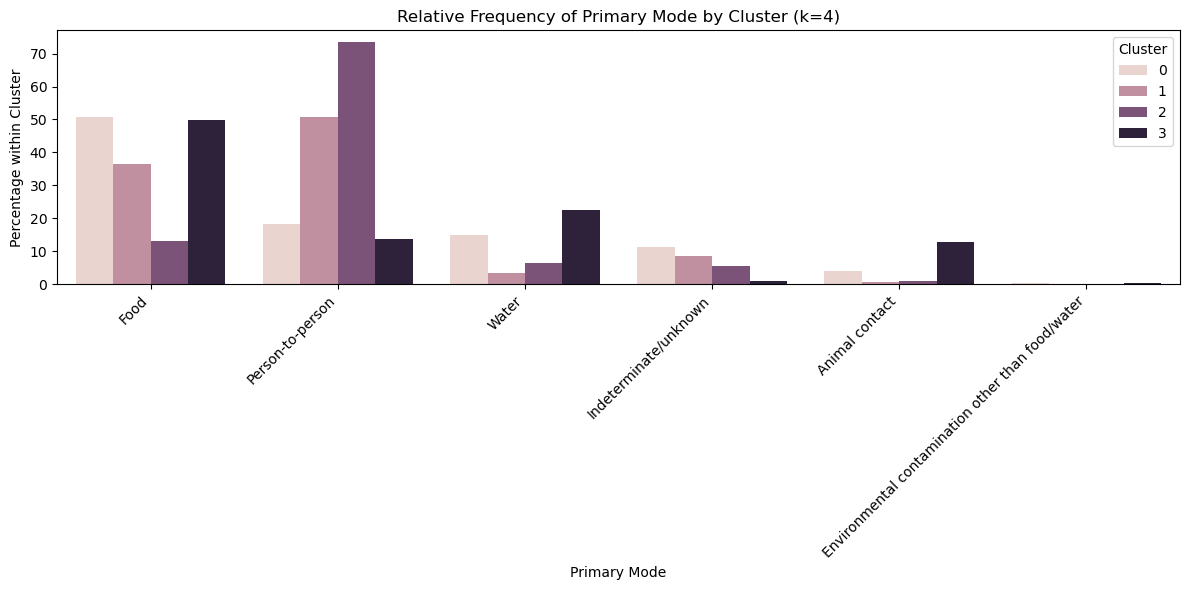

C:\Users\jared\AppData\Local\Temp\ipykernel_6788\2923266082.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


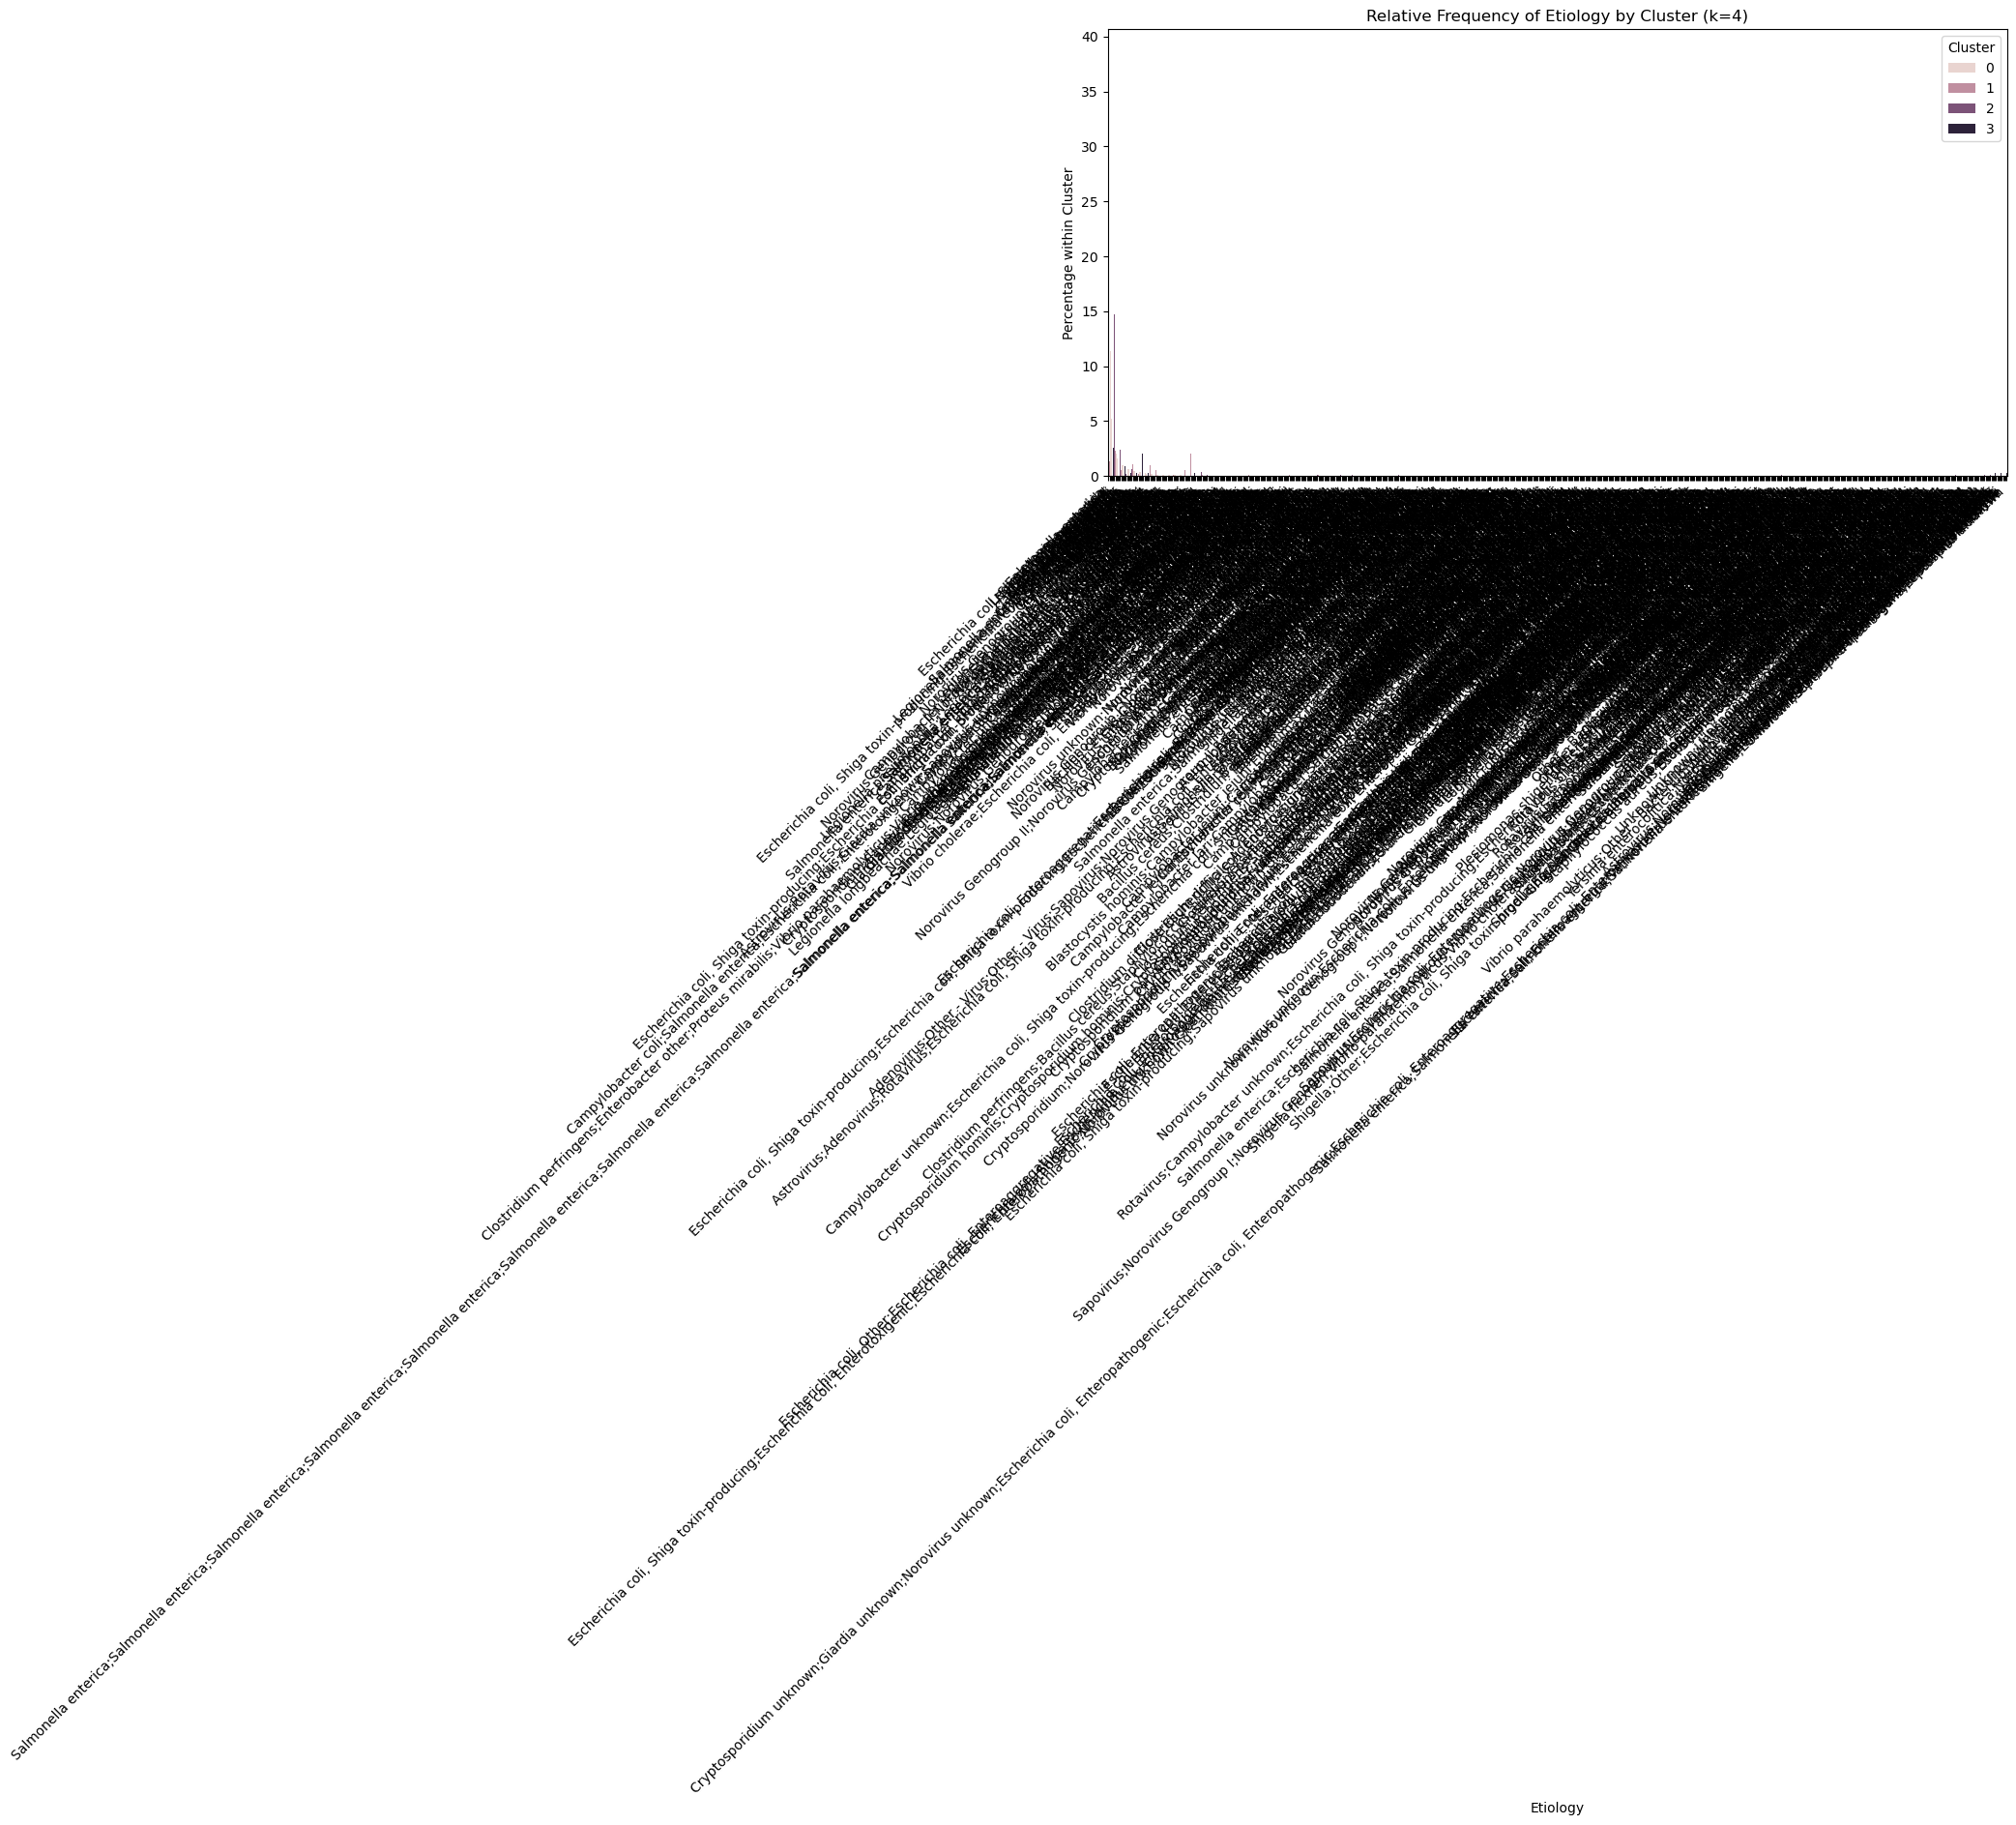

C:\Users\jared\AppData\Local\Temp\ipykernel_6788\2923266082.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


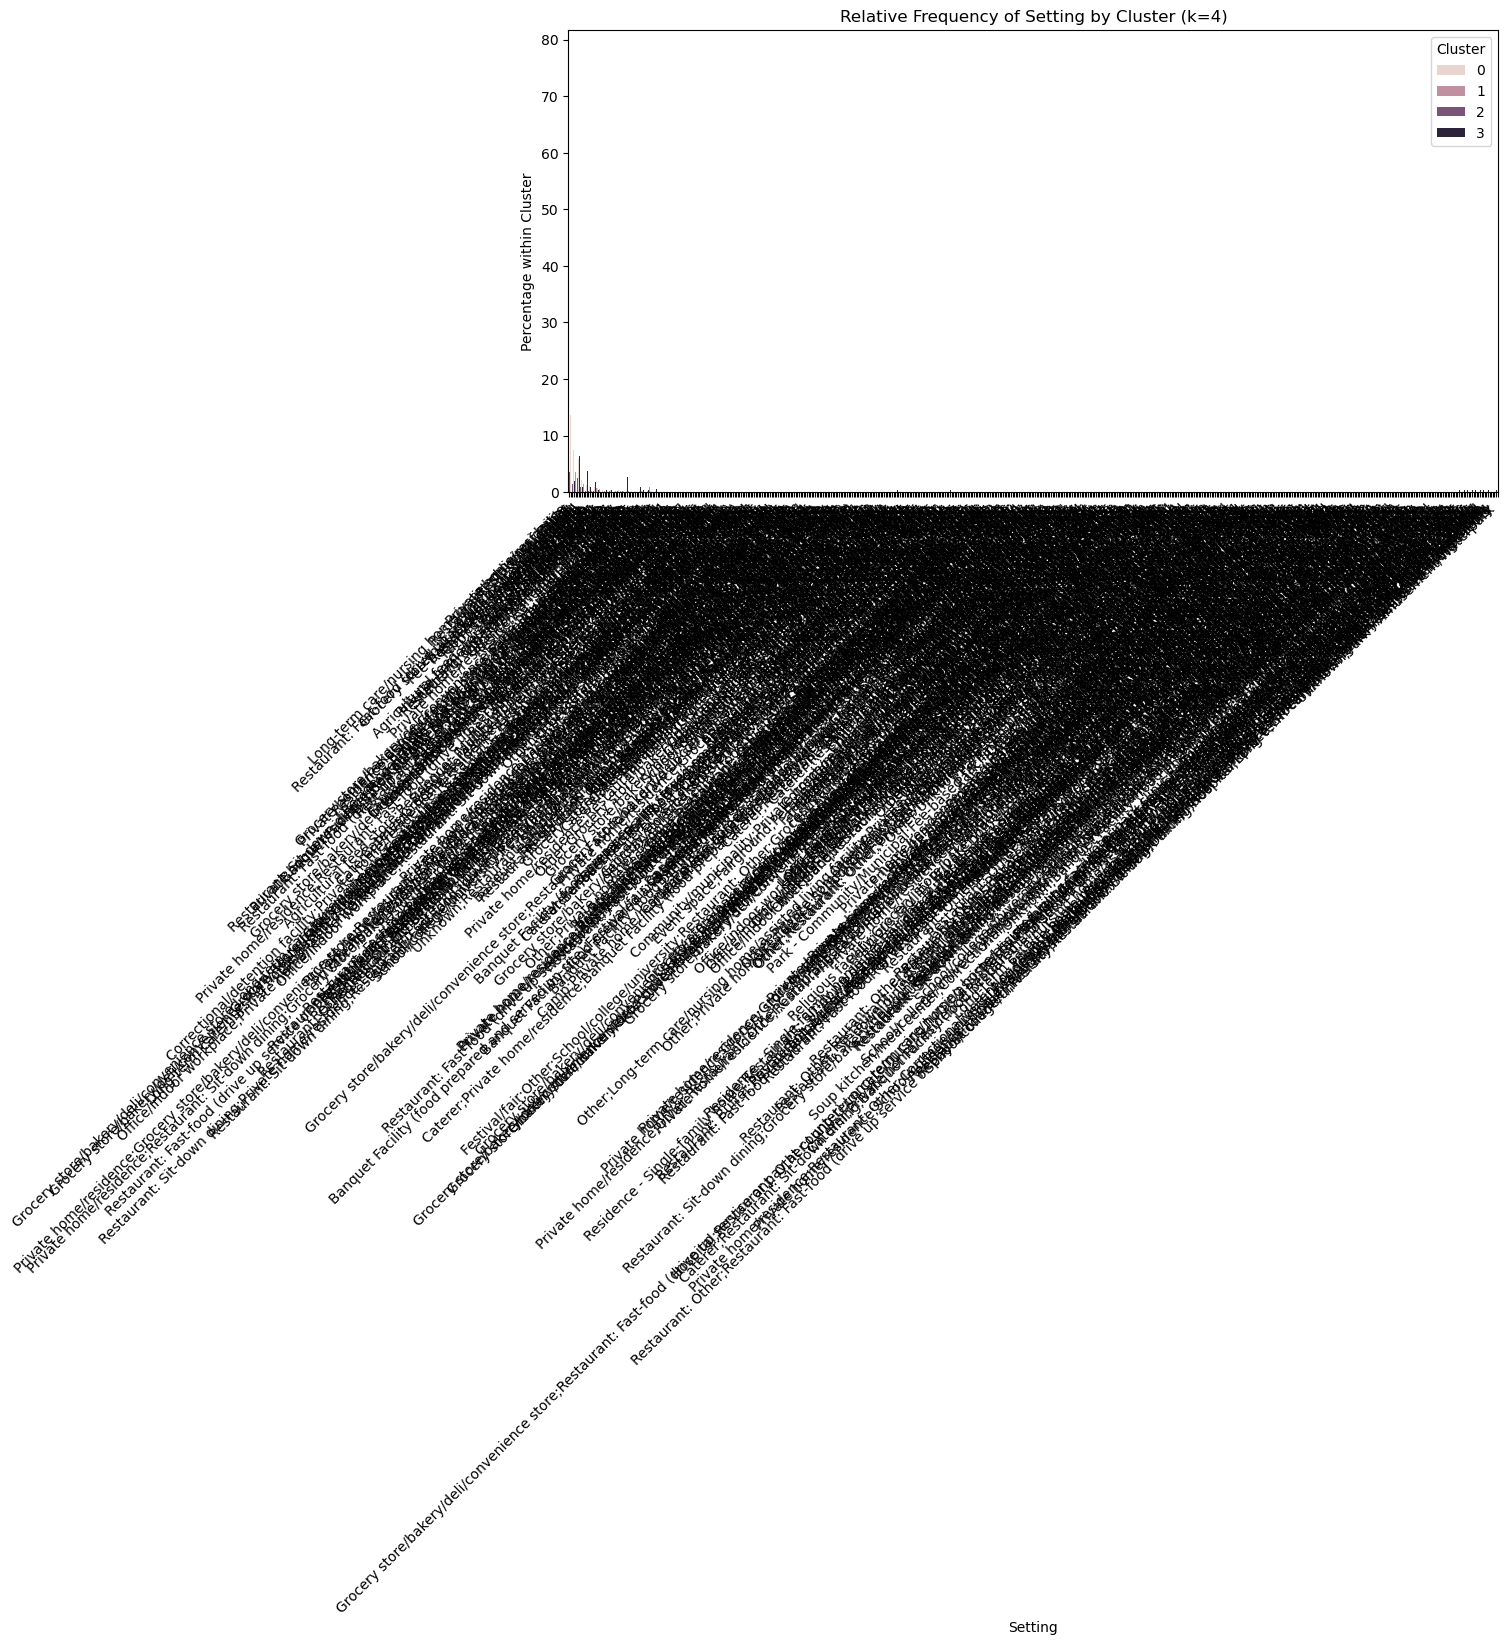


--- Mean Values of Numerical Features by Cluster ---
            Illnesses  Hospitalizations  Deaths  hosp_per_ill  death_per_ill
Cluster_k4                                                                  
0              11.282             3.664   0.000         0.536          0.000
1              24.260             0.254   0.000         0.013          0.000
2              42.048             2.243   1.168         0.118          0.052
3             427.944            17.067   0.059         0.207          0.001


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the categorical features for profiling
categorical_features = ['Primary Mode', 'Etiology', 'Setting']

# Define the numerical features to check means
numerical_features = ['Illnesses', 'Hospitalizations', 'Deaths', 'hosp_per_ill', 'death_per_ill']

print("--- Cluster Profiling for k=4 ---")

# 1. Profile Categorical Features (Relative Frequency Plots)
for feature in categorical_features:
    plt.figure(figsize=(12, 6))
    
    # Calculate the proportion of each category within each cluster
    cluster_profile = df_no_outlier_for_real.groupby('Cluster_k4')[feature].value_counts(normalize=True).mul(100).rename('percent').reset_index()
    
    # Plot the results
    sns.barplot(x=feature, y='percent', hue='Cluster_k4', data=cluster_profile)
    plt.title(f'Relative Frequency of {feature} by Cluster (k=4)')
    plt.xlabel(feature)
    plt.ylabel('Percentage within Cluster')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()

# 2. Profile Numerical Features (Cluster Means)
print("\n--- Mean Values of Numerical Features by Cluster ---")
print(df_no_outlier_for_real.groupby('Cluster_k4')[numerical_features].mean().round(3))